# 01 — A/B Testing Fundamentals in Product Analytics
**Prerequisites:** statistics_course/06_hypothesis_testing.ipynb (t-tests, p-values, CIs);
causal_inference_course/02_randomized_experiments.ipynb (why randomization identifies causal effects).
**Connects to:** experimental_design_course/08_online_experiments.ipynb (network effects, switchback
designs, interference — covered there in depth, only referenced here); this module's own
02_randomization_methods.ipynb, 03_power_analysis.ipynb.

## Narrative thread
```
What is an A/B test, in product terms -> the online experimentation pipeline (design -> ship -> analyze -> decide)
   -> typical online metrics -> ratio metrics & the delta method -> novelty/primacy effects -> pitfalls
```

## Why this notebook exists

This course (`causal_experimentation_course`) is about **running experimentation as a business
function** inside a tech company — the operational, statistical, and organizational machinery
around online controlled experiments (OCEs), also called A/B tests. It assumes you already know
*why* randomization identifies causal effects (`causal_inference_course/02`) and *how* to test a
hypothesis (`statistics_course/06`). What's new here is the **online product context**: users
arrive continuously, metrics are ratios and counts over millions of noisy individuals, and
decisions get made every week by product teams, not once by a single paper.

## What is an A/B test?

An A/B test randomly assigns each unit (usually a user) to a **control** experience (A, the
current product) or a **treatment** experience (B, the proposed change), and compares an outcome
metric $Y$ between arms. Because assignment is random, any systematic difference in $Y$ is
attributable to the treatment — the same logic as `causal_inference_course/02`, applied at
web/app scale.

$$\hat{\tau} = \bar{Y}_{treatment} - \bar{Y}_{control}$$

## The online experimentation pipeline

```
1. DESIGN     hypothesis, OEC (see notebook 04), MDE & sample size (notebook 03),
              randomization unit & method (notebook 02), guardrails (notebook 05)
2. SHIP       feature-flag the variant, log exposure events, run for a pre-registered duration
3. VALIDATE   check sample ratio mismatch (notebook 06), data-quality checks
4. ANALYZE    compute point estimate + CI/p-value per metric, correct for multiplicity (notebook 07)
5. DECIDE     ship / iterate / kill, weighing primary vs. guardrail metrics, novelty effects
```

Kohavi, Tang & Xu (2020) call this the **OCE (Online Controlled Experiment) lifecycle** and argue
that the biggest lever for a mature experimentation program is not smarter statistics but a
trustworthy, high-velocity *pipeline* — most experiments should be easy to run and cheap to be
wrong about.

## Typical online metrics

| Metric type | Example | Statistical shape |
|---|---|---|
| Binary / conversion | did the user purchase? | Bernoulli, tested with a two-proportion z-test |
| Count | number of sessions per user | overdispersed count, often log-transformed |
| Ratio | revenue per user = $\sum \text{revenue} / \sum \text{users}$ | ratio of two random variables — needs the delta method |
| Continuous, skewed | revenue per paying user | heavy right tail; consider trimming/winsorizing or the delta method on the mean |

Most "rate" metrics used in practice — click-through rate, conversion rate, revenue per user —
are **ratio metrics**: a sum divided by a count, both of which vary randomly across
randomization units. Treating them as simple i.i.d. means understates variance when the
numerator and denominator are correlated within unit (e.g., users who convert more also tend to
have more sessions).

## The delta method for ratio metrics

Let $R = \bar{X}/\bar{Y}$ be a ratio of two per-unit sample means (e.g., $X$ = revenue, $Y$ = 1
for every user so $\bar Y=1$, or $X$=clicks, $Y$=impressions). A first-order Taylor expansion
around the population means $(\mu_x, \mu_y)$ gives

$$\widehat{\text{Var}}(R) \approx \frac{1}{n\mu_y^2}\left[\text{Var}(X) - 2R\,\text{Cov}(X,Y) + R^2 \text{Var}(Y)\right]$$

which reduces to $\text{Var}(X)/n$ when $Y \equiv 1$ (a plain mean) but is **larger** whenever $X$
and $Y$ are positively correlated per unit — the usual case for revenue-per-user type metrics
computed at the user level with multiple observations per user. Ignoring this correlation is a
classic way experimentation platforms under-report variance and over-declare significance.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(42)

In [2]:
# ── Simulate a ratio metric: revenue per user, with per-user session counts ──
# Each user contributes n_sessions_i sessions and revenue_i; the ratio metric of interest
# is total revenue / total users, but per-user revenue and session count are correlated.
n_users = 5000

sessions = np.random.poisson(3, n_users) + 1                       # denominator-ish quantity
revenue = sessions * np.random.gamma(shape=2.0, scale=4.0, size=n_users)  # more sessions -> more revenue

df = pd.DataFrame({'sessions': sessions, 'revenue': revenue})

# naive variance: treat revenue as i.i.d., ignore sessions entirely
naive_var = df['revenue'].var(ddof=1) / n_users

# delta-method variance for R = mean(revenue)/mean(sessions) as a "revenue per session" metric
X, Y = df['revenue'].values, df['sessions'].values
R = X.mean() / Y.mean()
var_x, var_y = X.var(ddof=1), Y.var(ddof=1)
cov_xy = np.cov(X, Y, ddof=1)[0, 1]
delta_var = (var_x - 2*R*cov_xy + R**2*var_y) / (n_users * Y.mean()**2)

print(f"Revenue per session (ratio R):        {R:.3f}")
print(f"Naive Var(mean revenue), ignores ratio structure: {naive_var:.6f}")
print(f"Delta-method Var(R) for the ratio metric:         {delta_var:.6f}")
print(f"Cov(revenue, sessions) = {cov_xy:.3f}  (positive -> naive SE would be misleading if compared directly)")
print("\nNote: these two variances are for different estimands (mean revenue vs. revenue/session);")
print("the point is that the delta-method formula is required whenever the metric itself is a ratio.")

Revenue per session (ratio R):        8.065
Naive Var(mean revenue), ignores ratio structure: 0.159906
Delta-method Var(R) for the ratio metric:         0.007787
Cov(revenue, sessions) = 23.244  (positive -> naive SE would be misleading if compared directly)

Note: these two variances are for different estimands (mean revenue vs. revenue/session);
the point is that the delta-method formula is required whenever the metric itself is a ratio.


## Novelty and primacy effects

Two ways the *first days* of an experiment mislead you about its *steady-state* effect:

- **Novelty effect**: users react to the change simply because it's new/different (curiosity
  clicks), and the effect decays over the experiment.
- **Primacy effect**: existing users are anchored to the old UI and initially under-react (or
  actively resist) a genuinely better design; the effect *grows* as they adapt.

Both mean that a single point-in-time read of an experiment can misestimate the long-run
treatment effect. Practical mitigations: run long enough to see the effect stabilize, plot the
daily treatment effect over time, and — for confirmed ship decisions — consider a long-running
holdout (`10_uplift_holdouts.ipynb`).


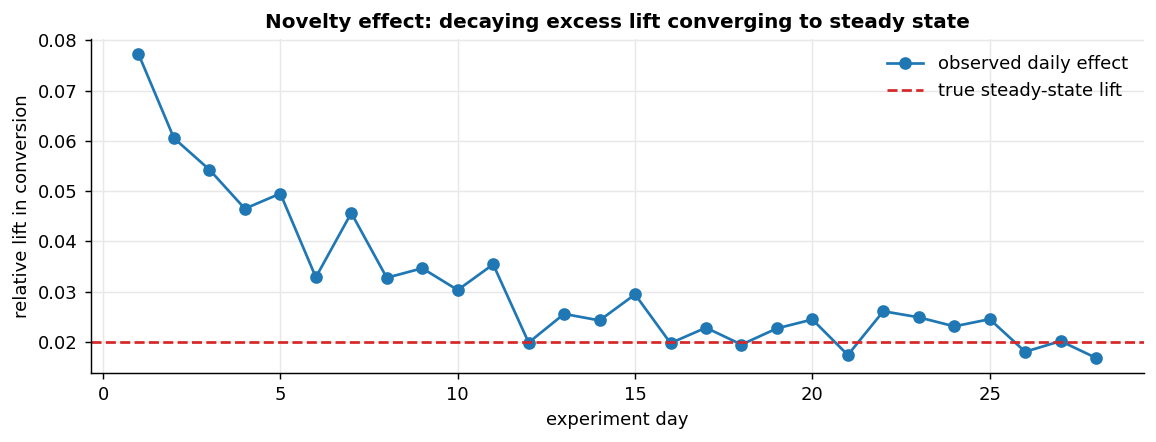

Reading only day 1-3 would overstate the durable effect by roughly: 0.0440


In [3]:
# ── Simulate a novelty effect: a decaying "excess" effect on top of a steady-state lift ──
days = np.arange(1, 29)
steady_state_lift = 0.02              # true long-run relative lift in conversion
novelty_bump = 0.06 * np.exp(-days / 6.0)   # decays over ~a week
daily_true_effect = steady_state_lift + novelty_bump

np.random.seed(1)
noise = np.random.normal(0, 0.004, size=len(days))
observed_daily_effect = daily_true_effect + noise

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(days, observed_daily_effect, 'o-', color='#1f77b4', label='observed daily effect')
ax.axhline(steady_state_lift, color='#d62728', ls='--', label='true steady-state lift')
ax.set_xlabel('experiment day'); ax.set_ylabel('relative lift in conversion')
ax.set_title('Novelty effect: decaying excess lift converging to steady state')
ax.legend(); plt.tight_layout(); plt.show()

print("Reading only day 1-3 would overstate the durable effect by roughly:",
      f"{(observed_daily_effect[:3].mean() - steady_state_lift):.4f}")

## Common pitfalls

- **Network effects / interference (SUTVA violations).** If treated users influence control
  users (social feed, marketplace liquidity, two-sided markets), the naive comparison is biased.
  This is a deep topic with cluster and switchback designs — see
  **`experimental_design_course/08_online_experiments.ipynb`** for the full treatment; we do not
  re-derive it here.
- **Selection bias in exposure**: only analyzing users who actually saw the treatment (not the
  full randomized population) reintroduces confounding — always analyze on an **intent-to-treat**
  basis at the randomization unit.
- **Multiple looks / peeking** at results inflate false positives — see `08_peeking_sequential_risk.ipynb`.
- **Sample ratio mismatch** silently invalidates an experiment — see `06_sample_ratio_mismatch.ipynb`.

## Key takeaways

| Concept | Statement |
|---|---|
| OCE pipeline | design -> ship -> validate -> analyze -> decide, repeated at high velocity |
| Ratio metrics | most product metrics are ratios; use the delta method, not a naive mean variance |
| Novelty/primacy | early experiment reads can over- or under-state the steady-state effect |
| Interference | network effects break i.i.d. analysis; see experimental_design_course/08 |

## References

- Kohavi, R., Tang, D., & Xu, Y. (2020). *Trustworthy Online Controlled Experiments*. Cambridge University Press.
- Deng, A., Xu, Y., Kohavi, R., & Walker, T. (2013). Improving the Sensitivity of Online Controlled Experiments by Utilizing Pre-Experiment Data. *WSDM 2013*.
- See also `experimental_design_course/08_online_experiments.ipynb` for network effects, switchback designs, and CUPED derivations.
